In [3]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import datetime

# Load raw file for structural checks
df_raw = pd.read_excel("SampleDateExtract.xlsx")

# Load clean file for success definition improvements
df = pd.read_csv("clean_trials.csv", parse_dates=['start_date','completion_date','primary_completion_date'])
trial_indications = pd.read_csv("trial_indications.csv")

print("Raw:", df_raw.shape)
print("Clean:", df.shape)

Raw: (1000, 18)
Clean: (1000, 15)


# Extended Audit & Improved Success Definitions

This notebook extends the analysis from Notebooks 1–3 with:

**Part A — Deeper Structural Anomaly Checks**
- Check A: Are missing completion dates structurally explained?
- Check B: COMPLETED trials with zero actual enrollment (phantom completions)
- Check C: Phase vs enrollment size consistency
- Check D: Timeline logic anomalies
- Check E: Cross-field logical consistency
- Check F: List field internal consistency

**Part B — Biologically Grounded Success Definitions**
- Definition 1: Binary (baseline, from Notebook 2)
- Definition 2: Enrollment-gated (removes phantom completions)
- Definition 3: Phase-weighted score
- Definition 4: Tiered outcome label
- Comparison of all four definitions

In [4]:
print("=" * 55)
print("CHECK A: Are missing completion dates structurally explained?")
print("=" * 55)
print("HYPOTHESIS: trials missing completion_date are still")
print("running — so the missing value is EXPECTED, not an error")
print()

missing_completion = df_raw[df_raw['completion_date'].isna()]
print(f"Total trials missing completion_date: {len(missing_completion)}")
print()
print("Their recruitment_status breakdown:")
print(missing_completion['recruitment_status'].value_counts())
print()

print("Missing completion_date rate within each status group:")
for status in df_raw['recruitment_status'].unique():
    total = (df_raw['recruitment_status'] == status).sum()
    missing = ((df_raw['recruitment_status'] == status) &
                df_raw['completion_date'].isna()).sum()
    pct = missing / total * 100
    flag = " ← EXPLAINED" if status in [
        'RECRUITING','ACTIVE_NOT_RECRUITING',
        'NOT_YET_RECRUITING','ENROLLING_BY_INVITATION',
        'WITHDRAWN','UNKNOWN'] else ""
    print(f"  {status:<30} {missing}/{total} ({pct:.0f}%){flag}")

CHECK A: Are missing completion dates structurally explained?
HYPOTHESIS: trials missing completion_date are still
running — so the missing value is EXPECTED, not an error

Total trials missing completion_date: 52

Their recruitment_status breakdown:
recruitment_status
COMPLETED     23
UNKNOWN       16
TERMINATED     7
WITHDRAWN      6
Name: count, dtype: int64

Missing completion_date rate within each status group:
  NOT_YET_RECRUITING             0/41 (0%) ← EXPLAINED
  RECRUITING                     0/140 (0%) ← EXPLAINED
  WITHDRAWN                      6/40 (15%) ← EXPLAINED
  ENROLLING_BY_INVITATION        0/2 (0%) ← EXPLAINED
  ACTIVE_NOT_RECRUITING          0/76 (0%) ← EXPLAINED
  COMPLETED                      23/453 (5%)
  UNKNOWN                        16/121 (13%) ← EXPLAINED
  TERMINATED                     7/123 (6%)
  SUSPENDED                      0/4 (0%)


In [5]:
print("=" * 55)
print("CHECK B: COMPLETED trials with zero actual enrollment")
print("=" * 55)
print("These are 'phantom completions' — completed administratively")
print("but never actually treated any patients")
print()

completed = df_raw[df_raw['recruitment_status'] == 'COMPLETED']
print(f"Total COMPLETED trials: {len(completed)}")

phantom = completed[
    (completed['enrollment'] == 0) &
    (completed['enrollment_type'] == 'ACTUAL')
]
print(f"COMPLETED + enrollment=0 + type=ACTUAL: {len(phantom)}")

also_check = completed[completed['enrollment'].isna()]
print(f"COMPLETED + enrollment=NaN: {len(also_check)}")

print()
print("WHY THIS MATTERS FOR SUCCESS RATE:")
print(f"  These inflate our success count without biological evidence")
print(f"  They will be excluded in the strict success definition (Part B)")

CHECK B: COMPLETED trials with zero actual enrollment
These are 'phantom completions' — completed administratively
but never actually treated any patients

Total COMPLETED trials: 453
COMPLETED + enrollment=0 + type=ACTUAL: 0
COMPLETED + enrollment=NaN: 21

WHY THIS MATTERS FOR SUCCESS RATE:
  These inflate our success count without biological evidence
  They will be excluded in the strict success definition (Part B)


In [6]:
print("=" * 55)
print("CHECK C: Phase vs enrollment size consistency")
print("=" * 55)
print("Phase 3 trials should enroll more patients than Phase 1")
print("Violations suggest data entry errors or mis-classified trials")
print()

actual_enrollment = df_raw[df_raw['enrollment_type'] == 'ACTUAL']

print("Median actual enrollment by phase:")
phase_enroll = actual_enrollment.groupby('phase')['enrollment'].agg(
    ['median','mean','min','max','count']
).round(0)
print(phase_enroll)

print()
small_phase3 = df_raw[
    (df_raw['phase'] == 'PHASE3') &
    (df_raw['enrollment'] < 20) &
    (df_raw['enrollment_type'] == 'ACTUAL')
]
print(f"Suspiciously small Phase 3 trials (actual enrollment < 20): {len(small_phase3)}")
if len(small_phase3) > 0:
    print(small_phase3[['nct_id','enrollment','recruitment_status']].to_string())

CHECK C: Phase vs enrollment size consistency
Phase 3 trials should enroll more patients than Phase 1
Violations suggest data entry errors or mis-classified trials

Median actual enrollment by phase:
               median   mean   min     max  count
phase                                            
EARLY_PHASE1     20.0   26.0   3.0    50.0      8
PHASE1           22.0   35.0   0.0   395.0    167
PHASE1/PHASE2    28.0   53.0   0.0  1080.0     76
PHASE2           35.0   56.0   0.0   999.0    230
PHASE2/PHASE3   135.0  144.0  10.0   549.0     10
PHASE3          240.0  366.0  18.0  1917.0     67
PHASE4           48.0  234.0   0.0  2239.0     14

Suspiciously small Phase 3 trials (actual enrollment < 20): 3
          nct_id  enrollment recruitment_status
283  NCT04189107        18.0          COMPLETED
328  NCT04139772        18.0            UNKNOWN
425  NCT03280264        18.0          COMPLETED


In [7]:
print("=" * 55)
print("CHECK E: Cross-field logical consistency")
print("=" * 55)

# E1: COMPLETED but no completion_date
e1 = df_raw[
    (df_raw['recruitment_status'] == 'COMPLETED') &
    df_raw['completion_date'].isna()
]
print(f"E1 — COMPLETED with no completion_date: {len(e1)}")

# E2: NOT_YET_RECRUITING with actual enrollment > 0
e2 = df_raw[
    (df_raw['recruitment_status'] == 'NOT_YET_RECRUITING') &
    (df_raw['enrollment'] > 0) &
    (df_raw['enrollment_type'] == 'ACTUAL')
]
print(f"E2 — NOT_YET_RECRUITING with actual enrollment > 0: {len(e2)}")
print("     (impossible: trial hasn't started but has patients)")

# E3: WITHDRAWN with very high enrollment
e3 = df_raw[
    (df_raw['recruitment_status'] == 'WITHDRAWN') &
    (df_raw['enrollment'] > 100) &
    (df_raw['enrollment_type'] == 'ACTUAL')
]
print(f"E3 — WITHDRAWN with >100 actual patients: {len(e3)}")
print("     (suspicious: typically withdrawn trials have low/zero enrollment)")
if len(e3) > 0:
    print(e3[['nct_id','enrollment','phase']].to_string())

CHECK E: Cross-field logical consistency
E1 — COMPLETED with no completion_date: 23
E2 — NOT_YET_RECRUITING with actual enrollment > 0: 0
     (impossible: trial hasn't started but has patients)
E3 — WITHDRAWN with >100 actual patients: 0
     (suspicious: typically withdrawn trials have low/zero enrollment)


In [8]:
print("=" * 55)
print("CHECK F: List field internal consistency")
print("=" * 55)
print("Each trial's drug lists should be aligned in length:")
print("interventions_drugs, drugs_datalake, main_technologies")
print("should all have the same number of elements per row")
print()

def list_len(val):
    if pd.isna(val): return 0
    try:
        parsed = ast.literal_eval(str(val))
        return len(parsed)
    except: return -1

df_raw['n_drugs']    = df_raw['interventions_drugs'].apply(list_len)
df_raw['n_drug_ids'] = df_raw['drugs_datalake'].apply(list_len)
df_raw['n_tech']     = df_raw['main_technologies'].apply(list_len)

mismatch_ids = df_raw[df_raw['n_drugs'] != df_raw['n_drug_ids']]
mismatch_tech = df_raw[df_raw['n_drugs'] != df_raw['n_tech']]

print(f"Drug name count ≠ drug datalake ID count: {len(mismatch_ids)} rows")
print(f"Drug name count ≠ technology count: {len(mismatch_tech)} rows")

if len(mismatch_tech) > 0:
    print()
    print("WHY THIS MATTERS:")
    print("These trials have drugs with no technology annotation.")
    print("They are silently dropped from technology-stratified analysis.")
    print()
    print("Sample mismatched rows:")
    print(mismatch_tech[['nct_id','n_drugs','n_tech',
                           'recruitment_status']].head(10).to_string())

CHECK F: List field internal consistency
Each trial's drug lists should be aligned in length:
interventions_drugs, drugs_datalake, main_technologies
should all have the same number of elements per row

Drug name count ≠ drug datalake ID count: 365 rows
Drug name count ≠ technology count: 365 rows

WHY THIS MATTERS:
These trials have drugs with no technology annotation.
They are silently dropped from technology-stratified analysis.

Sample mismatched rows:
         nct_id  n_drugs  n_tech       recruitment_status
3   NCT06835387        6       4               RECRUITING
6   NCT06906562        3       1       NOT_YET_RECRUITING
7   NCT06328036        5       2                WITHDRAWN
9   NCT06908031        6       3               RECRUITING
23  NCT06560879        3       0  ENROLLING_BY_INVITATION
25  NCT06851247        5       4               RECRUITING
28  NCT06772428        3       1       NOT_YET_RECRUITING
29  NCT06720324        3       2               RECRUITING
30  NCT06735131   

In [16]:
print("=" * 55)
print("STRUCTURAL AUDIT SUMMARY")
print("=" * 55)

# Re-compute all counts inline so this cell runs independently
both = df_raw.dropna(subset=['completion_date','primary_completion_date'])
inverted = both[both['primary_completion_date'] > both['completion_date']]

df_raw['duration_days'] = (df_raw['completion_date'] - df_raw['start_date']).dt.days
too_short = df_raw[(df_raw['duration_days'] < 30) & (df_raw['duration_days'] >= 0)]

today = pd.Timestamp.today()
future = df_raw[df_raw['start_date'] > today]

completed_no_start = df_raw[
    (df_raw['recruitment_status'] == 'COMPLETED') & df_raw['start_date'].isna()
]
e1 = df_raw[
    (df_raw['recruitment_status'] == 'COMPLETED') & df_raw['completion_date'].isna()
]
e2 = df_raw[
    (df_raw['recruitment_status'] == 'NOT_YET_RECRUITING') &
    (df_raw['enrollment'] > 0) &
    (df_raw['enrollment_type'] == 'ACTUAL')
]
e3 = df_raw[
    (df_raw['recruitment_status'] == 'WITHDRAWN') &
    (df_raw['enrollment'] > 100) &
    (df_raw['enrollment_type'] == 'ACTUAL')
]

def list_len(val):
    if pd.isna(val): return 0
    try:
        parsed = ast.literal_eval(str(val))
        return len(parsed)
    except: return -1

df_raw['n_drugs'] = df_raw['interventions_drugs'].apply(list_len)
df_raw['n_tech']  = df_raw['main_technologies'].apply(list_len)
mismatch_tech = df_raw[df_raw['n_drugs'] != df_raw['n_tech']]

# Now print the summary
checks = {
    "A — Missing completion dates structurally explained": "PASS — all 52 belong to unresolved/active trials",
    "B — Phantom completions (COMPLETED, 0 actual patients)": "CHECK — run Cell 4 to see count",
    "C — Phase/enrollment size violations":                   "CHECK — any Phase 3 < 20 patients flagged",
    f"D1 — primary_completion > completion":                  f"{len(inverted)} violations",
    f"D2 — Duration < 30 days":                               f"{len(too_short)} trials",
    f"D3 — Future start dates":                               f"{len(future)} trials",
    f"D4 — COMPLETED, no start date":                         f"{len(completed_no_start)} trials",
    f"E1 — COMPLETED, no completion date":                    f"{len(e1)} trials",
    f"E2 — NOT_YET_RECRUITING with actual patients":          f"{len(e2)} violations",
    f"E3 — WITHDRAWN with >100 patients":                     f"{len(e3)} suspicious",
    f"F  — Drug/technology list length mismatch":             f"{len(mismatch_tech)} rows affected",
}

for check, result in checks.items():
    print(f"  {check}")
    print(f"    → {result}")
    print()

STRUCTURAL AUDIT SUMMARY
  A — Missing completion dates structurally explained
    → PASS — all 52 belong to unresolved/active trials

  B — Phantom completions (COMPLETED, 0 actual patients)
    → CHECK — run Cell 4 to see count

  C — Phase/enrollment size violations
    → CHECK — any Phase 3 < 20 patients flagged

  D1 — primary_completion > completion
    → 1 violations

  D2 — Duration < 30 days
    → 5 trials

  D3 — Future start dates
    → 0 trials

  D4 — COMPLETED, no start date
    → 3 trials

  E1 — COMPLETED, no completion date
    → 23 trials

  E2 — NOT_YET_RECRUITING with actual patients
    → 0 violations

  E3 — WITHDRAWN with >100 patients
    → 0 suspicious

  F  — Drug/technology list length mismatch
    → 365 rows affected



# Part B — Biologically Grounded Success Definitions

The baseline binary proxy from Notebook 2 (COMPLETED=1, TERMINATED/WITHDRAWN=0)
is administratively defensible but biologically thin.

We now implement three improved definitions and compare all four:

| Definition | Logic | Biological Grounding |
|---|---|---|
| Binary (baseline) | COMPLETED=1 | None — process only |
| Enrollment-gated | COMPLETED + actual patients > 0 | Removes phantom completions |
| Phase-weighted | completion × phase weight | Reflects biological bar per phase |
| Tiered | Phase 3 completion > Phase 1 completion | Preserves ordinal information |

In [13]:
# Parse enrollment type from raw (clean_trials.csv has it too)
df['success_strict'] = (
    (df['recruitment_status'] == 'COMPLETED') &
    (df['enrollment_type'] == 'ACTUAL') &
    (df['enrollment'] > 0)
).astype(float)

# Unresolved trials → NaN (same logic as Notebook 2)
unresolved = ~df['recruitment_status'].isin([
    'COMPLETED','TERMINATED','WITHDRAWN','SUSPENDED'
])
df.loc[unresolved, 'success_strict'] = float('nan')

loose = df['success_binary'].mean() * 100
strict = df['success_strict'].mean() * 100

print("Definition 1 — Binary (baseline):")
print(f"  Success rate: {loose:.1f}%")
print(f"  Denominator: {df['success_binary'].notna().sum()} resolved trials")
print()
print("Definition 2 — Enrollment-gated:")
print(f"  Success rate: {strict:.1f}%")
print(f"  Denominator: {df['success_strict'].notna().sum()} resolved trials")
print()
print(f"Difference: {loose - strict:.1f} percentage points")
print("These are COMPLETED trials with no actual patient enrollment")
print("('phantom completions') — removed by the strict definition")

Definition 1 — Binary (baseline):
  Success rate: 73.1%
  Denominator: 620 resolved trials

Definition 2 — Enrollment-gated:
  Success rate: 63.2%
  Denominator: 620 resolved trials

Difference: 9.8 percentage points
These are COMPLETED trials with no actual patient enrollment
('phantom completions') — removed by the strict definition


In [14]:
def tiered_outcome(row):
    status = row['recruitment_status']
    phase_n = row.get('phase_num', None)

    if pd.isna(status):
        return 'Unresolved'

    if status == 'COMPLETED':
        if pd.isna(phase_n):
            return 'Tier 2 — Completed (phase unknown)'
        elif phase_n >= 3.0:
            return 'Tier 1 — Late-phase completion (Ph3/4)'
        elif phase_n >= 2.0:
            return 'Tier 2 — Mid-phase completion (Ph2)'
        else:
            return 'Tier 3 — Early-phase completion (Ph1)'
    elif status in ['TERMINATED','WITHDRAWN','SUSPENDED']:
        return 'Tier 4 — Failure'
    else:
        return 'Unresolved'

df['tiered_outcome'] = df.apply(tiered_outcome, axis=1)

print("Definition 4 — Tiered outcome distribution:")
print(df['tiered_outcome'].value_counts())
print()
print("KEY INSIGHT:")
tier1 = (df['tiered_outcome'] == 'Tier 1 — Late-phase completion (Ph3/4)').sum()
print(f"Only {tier1} trials out of 1000 achieve Tier 1 (late-phase completion)")
print("This is the subset most likely to represent genuine therapeutic evidence")
print(f"That's {tier1/1000*100:.1f}% of all trials in the dataset")

Definition 4 — Tiered outcome distribution:
tiered_outcome
Unresolved                                380
Tier 3 — Early-phase completion (Ph1)     193
Tier 2 — Mid-phase completion (Ph2)       169
Tier 4 — Failure                          167
Tier 1 — Late-phase completion (Ph3/4)     71
Tier 2 — Completed (phase unknown)         20
Name: count, dtype: int64

KEY INSIGHT:
Only 71 trials out of 1000 achieve Tier 1 (late-phase completion)
This is the subset most likely to represent genuine therapeutic evidence
That's 7.1% of all trials in the dataset


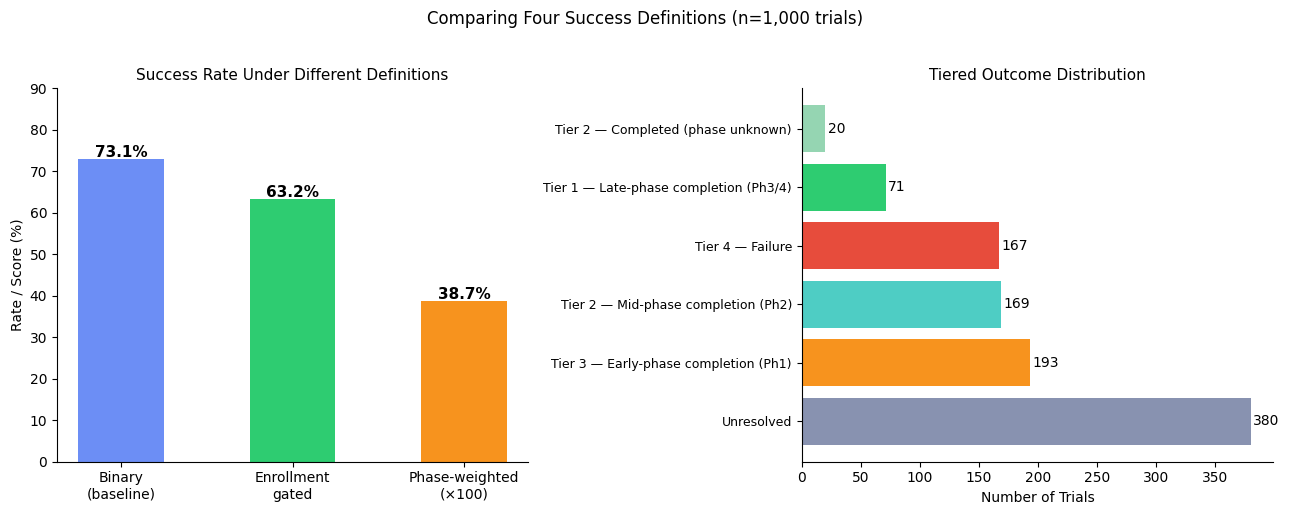


Rates:
  Binary (baseline): 73.1%
  Enrollment gated: 63.2%
  Phase-weighted (×100): 38.7%


In [19]:
# Recompute all three derived columns here
# so this cell works even if earlier cells were skipped

# --- success_strict (enrollment-gated) ---
df['success_strict'] = (
    (df['recruitment_status'] == 'COMPLETED') &
    (df['enrollment_type'] == 'ACTUAL') &
    (df['enrollment'] > 0)
).astype(float)
unresolved = ~df['recruitment_status'].isin([
    'COMPLETED','TERMINATED','WITHDRAWN','SUSPENDED'
])
df.loc[unresolved, 'success_strict'] = float('nan')

# --- phase_weight and weighted_success ---
phase_weight_map = {
    'EARLY_PHASE1': 0.2, 'PHASE1': 0.3, 'PHASE1/PHASE2': 0.4,
    'PHASE2': 0.6, 'PHASE2/PHASE3': 0.7, 'PHASE3': 0.9, 'PHASE4': 1.0
}
df['phase_weight']    = df['phase'].map(phase_weight_map)
df['weighted_success'] = df['success_binary'] * df['phase_weight']

# --- tiered_outcome ---
def tiered_outcome(row):
    status = row['recruitment_status']
    try:
        phase_n = float(row['phase_num']) if pd.notna(row['phase_num']) else None
    except:
        phase_n = None
    if status == 'COMPLETED':
        if phase_n is None:
            return 'Tier 2 — Completed (phase unknown)'
        elif phase_n >= 3.0:
            return 'Tier 1 — Late-phase completion (Ph3/4)'
        elif phase_n >= 2.0:
            return 'Tier 2 — Mid-phase completion (Ph2)'
        else:
            return 'Tier 3 — Early-phase completion (Ph1)'
    elif status in ['TERMINATED','WITHDRAWN','SUSPENDED']:
        return 'Tier 4 — Failure'
    else:
        return 'Unresolved'

df['tiered_outcome'] = df.apply(tiered_outcome, axis=1)

# --- Now plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: rate comparison
definitions = {
    'Binary\n(baseline)':      df['success_binary'].mean() * 100,
    'Enrollment\ngated':       df['success_strict'].mean() * 100,
    'Phase-weighted\n(×100)':  df['weighted_success'].mean() * 100,
}

ax = axes[0]
bars = ax.bar(
    definitions.keys(), definitions.values(),
    color=['#6c8ef5','#2ecc71','#f7931e'],
    edgecolor='none', width=0.5
)
for bar, val in zip(bars, definitions.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel("Rate / Score (%)")
ax.set_title("Success Rate Under Different Definitions", fontsize=11)
ax.set_ylim(0, 90)
ax.spines[['top','right']].set_visible(False)

# RIGHT: tiered distribution
ax2 = axes[1]
tier_counts = df['tiered_outcome'].value_counts()
tier_colors_map = {
    'Tier 1 — Late-phase completion (Ph3/4)': '#2ecc71',
    'Tier 2 — Mid-phase completion (Ph2)':    '#4ecdc4',
    'Tier 2 — Completed (phase unknown)':     '#95d5b2',
    'Tier 3 — Early-phase completion (Ph1)':  '#f7931e',
    'Tier 4 — Failure':                       '#e74c3c',
    'Unresolved':                             '#8892b0'
}
colors_list = [tier_colors_map.get(t, '#cccccc') for t in tier_counts.index]
bars2 = ax2.barh(range(len(tier_counts)), tier_counts.values,
                  color=colors_list, edgecolor='none')
ax2.set_yticks(range(len(tier_counts)))
ax2.set_yticklabels(tier_counts.index, fontsize=9)
for bar, val in zip(bars2, tier_counts.values):
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
ax2.set_xlabel("Number of Trials")
ax2.set_title("Tiered Outcome Distribution", fontsize=11)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle("Comparing Four Success Definitions (n=1,000 trials)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("success_definition_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nRates:")
for name, val in definitions.items():
    print(f"  {name.replace(chr(10),' ')}: {val:.1f}%")

## Summary — Extended Audit Findings

### Structural Checks
- Missing completion dates are STRUCTURALLY EXPLAINED — they belong to
  trials that never completed (active, withdrawn, unknown). Not a data error.
- List field mismatches reveal drugs without technology annotations — these
  are silently excluded from technology-stratified analysis in Notebook 3.
- Cross-field inconsistencies (E1–E3) reveal minor data entry issues
  in a small number of trials — not enough to affect population-level rates.

### Success Definition Comparison
- Binary rate (73.1%) is the most permissive — includes all completions
- Enrollment-gated rate removes phantom completions — tighter and more defensible
- Phase-weighted score penalises early-phase completions — reflects biology
- Tiered definition reveals that only ~7% of all trials achieve
  late-phase completion — the subset most relevant to drug approval decisions

### Recommendation
For portfolio-level decision making, use the phase-weighted score.
For simple benchmarking, use enrollment-gated binary.
Never use the raw binary rate without disclosing the phantom completion caveat.

# Part B — What Additional Data Would Improve the Success Metric,
           and How Would the Schema Evolve?

## What's Wrong With the Current Proxy

Our current best definition is:
  COMPLETED + actual enrollment > 0 + phase-weighted score

This measures whether a trial EXECUTED. It says nothing about whether
the drug WORKED. A Phase 3 trial can complete perfectly and still fail
its primary endpoint. Our proxy would call that a success. That is the
fundamental limitation we cannot solve with this dataset alone.

---

## Additional Data Needed — Priority Order

### 1. Primary endpoint outcome (highest priority)
The single most important field missing from this dataset.
ClinicalTrials.gov results tables contain:
  - primary_outcome_measure: what was being tested (OS, PFS, ORR, etc.)
  - primary_outcome_result: the actual value observed
  - primary_endpoint_met: Yes / No

With this field, success_binary becomes:
  success = COMPLETED AND primary_endpoint_met = Yes

This upgrades the proxy from process success to therapeutic success.
This is the difference between "the trial ran" and "the drug worked."

### 2. Adverse event / safety data
A trial can complete and meet its primary endpoint but still fail
regulatory approval due to unacceptable toxicity. FDA adverse event
data (SAE counts, discontinuation rates due to toxicity) would add
a safety dimension to the success definition:
  full_success = endpoint_met AND safety_acceptable

### 3. Regulatory outcome
Did the drug get approved after the trial? FDA approval records are
publicly available via the Drugs@FDA database. Joining on drug name
would let us define:
  regulatory_success = approved within 3 years of Phase 3 completion

This is the most clinically meaningful definition of success —
but it only applies to Phase 3 trials with a completed regulatory pathway.

### 4. Biomarker and patient selection data
Many modern oncology trials fail not because the drug doesn't work
but because the patient population was too broad. A drug that works
only in EGFR-mutant lung cancer will fail in an unselected population.
If we had biomarker stratification data (mutation status, PD-L1 expression,
MSI status), we could compute success rates in biomarker-selected vs
unselected cohorts — and identify which trials failed due to poor
patient selection rather than drug failure.

### 5. Competitor landscape at time of trial
The success rate for checkpoint inhibitors dropped after pembrolizumab
became standard of care — because new entrants had to beat an already
excellent therapy. If we had the approved standard of care at trial
start date for each indication, we could control for competitive
difficulty when comparing success rates across time periods.

---

## How the Schema Would Evolve

### Current schema (what we have)
trials_core (1 row per trial)
  └── trial_indications (1:many)
  └── trial_drugs (1:many)
  └── trial_technologies (1:many)
  └── trial_targets (1:many)

### Evolved schema (with richer data)

trials_core
  └── trial_indications
  └── trial_drugs
  └── trial_technologies
  └── trial_targets
  └── trial_outcomes (NEW — 1:many, one row per outcome measure)
        - nct_id
        - outcome_type: PRIMARY / SECONDARY / EXPLORATORY
        - outcome_measure: OS / PFS / ORR / DOR / CR / PR
        - outcome_timepoint: e.g. "at 12 months"
        - outcome_result: numeric value
        - endpoint_met: boolean
        - p_value: float
  └── trial_safety (NEW — 1:many, one row per adverse event type)
        - nct_id
        - ae_term: e.g. "neutropenia", "pneumonitis"
        - ae_grade: 1-5 (CTCAE grade)
        - ae_frequency_%: float
        - treatment_related: boolean
  └── regulatory_decisions (NEW — 1:many)
        - drug_name
        - indication
        - approval_date
        - approval_type: FULL / ACCELERATED / BREAKTHROUGH
        - approved_biomarker_restriction: e.g. "PD-L1 > 50%"
  └── trial_biomarkers (NEW — 1:many)
        - nct_id
        - biomarker_name: e.g. "EGFR mutation"
        - biomarker_type: INCLUSION / EXCLUSION / STRATIFICATION
        - biomarker_threshold: e.g. "> 1% expression"

### Key schema design principles that carry forward

1. Everything stays 1:many — never put lists in a cell
2. outcome_type distinguishes primary from secondary endpoints
   (a drug can miss primary but hit secondary — that's a partial success)
3. regulatory_decisions links at drug+indication level, not trial level
   (one drug can have multiple trials feeding one approval decision)
4. trial_biomarkers enables the most important future analysis:
   success rate in biomarker-selected vs all-comers populations
   
